# PCA + DBSCAN Clustering of Stock Price Movement (Google Colab, upload-and-run)

**How to use.** Runtime -> Run all. The second code cell opens an upload widget;
choose a CSV shaped like this project's `*_clustering_ready.csv` files (one row per
stock, one column per identifier plus one column per trading day of standardised
price). Everything after that cell runs automatically with no further input. To
process a different CSV, just re-run the notebook and upload it again.

**Method and citations.** Every modelling choice below is tied to a specific
reference, listed with full detail in the **References** section at the end. In
short:

- DBSCAN itself, its core/border/noise definitions, and its `eps`/`MinPts`
  parameter-selection heuristics are taken directly from **Ester, Kriegel, Sander &
  Xu (1996)** [1], the paper that introduced the algorithm.
- The silhouette coefficient, the silhouette plot, and the rule of picking the
  parameter setting that maximises the average silhouette width are taken directly
  from **Rousseeuw (1987)** [2].
- The `DBSCAN` and evaluation-metric implementations used are `scikit-learn`'s, per
  its **Clustering** [3] and **Clustering performance evaluation** [4] user guides.
- **PCA**, the **Calinski-Harabasz**/**Davies-Bouldin** indices, the **Adjusted Rand
  Index**, and **bootstrap/sub-sampling** for cluster stability are each attributed
  to their own original source ([5], [6], [7], [8], [9]) — standard, well-established
  references separate from the materials supplied for this task, flagged as such
  throughout.
- **Parameter selection and quality evaluation are kept on disjoint data.** Choosing
  `(eps, MinPts)` by whichever value maximises silhouette width, then reporting that
  same silhouette score as evidence of "clustering quality," is circular: the score
  is high largely *because* it was the selection criterion, not because it
  demonstrates the partition generalises. This notebook instead follows the
  hold-out/cross-validation principle of **Stone (1974)** [10]: the data is split
  once into a *selection* subset, used only to choose `(eps, MinPts)`, and a
  disjoint *held-out* subset that never influences that choice and is the only one
  used to report quality metrics.
- **Every quality metric is reported together with its coverage** — the fraction of
  companies it was actually computed over. The silhouette coefficient [2] is, by its
  own definition, undefined for a noise point (it has no cluster to compute `a(i)`
  against), so it is only ever computed on non-noise points; this notebook always
  states that denominator explicitly rather than letting a single number stand in
  for the whole sample.


In [1]:
import io
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")

Libraries loaded.


## 1. Upload a CSV

Expected shape: one identifier column (e.g. `Ticker`) followed by one numeric column
per trading day, holding each stock's standardised (z-scored) closing price — exactly
the format of this project's `ftse_clustering_ready.csv`,
`ftse250_clustering_ready.csv` and `ftse2501_clustering_ready.csv`. Re-run this cell
(or Runtime -> Run all) to load a different file; every later cell then regenerates
automatically from whatever was just uploaded.

In [2]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Select a CSV file to upload...")
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
    raw_bytes = uploaded[FILENAME]
else:
    # Fallback so the notebook can also be run and tested outside Colab.
    FILENAME = "ftse250_clustering_ready.csv"
    raw_bytes = open(FILENAME, "rb").read()

print("Using file:", FILENAME)

Using file: ftse250_clustering_ready.csv


## 2. Parse and clean

The identifier column is auto-detected as the first non-numeric column (falling back
to the first column if every column parses as numeric); every other column is treated
as one point in an ordered numeric sequence (a trading day). Rows missing more than
`MAX_MISSING_FRAC` of their history are dropped; any remaining gaps are forward- then
backward-filled. This is routine data hygiene, not a modelling choice, so it carries
no citation of its own.

In [3]:
MAX_MISSING_FRAC = 0.10

df = pd.read_csv(io.BytesIO(raw_bytes))

id_col = None
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]):
        id_col = c
        break
if id_col is None:
    id_col = df.columns[0]

feature_cols = [c for c in df.columns if c != id_col]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

frac_missing = df[feature_cols].isna().sum(axis=1) / len(feature_cols)
n_dropped = int((frac_missing > MAX_MISSING_FRAC).sum())
df = df.loc[frac_missing <= MAX_MISSING_FRAC].reset_index(drop=True)
df[feature_cols] = df[feature_cols].ffill(axis=1).bfill(axis=1)

entity_ids = df[id_col].values
X_raw = df[feature_cols].values.astype(float)
n_total = X_raw.shape[0]

print(f"Identifier column: '{id_col}'")
print(f"{n_total} entities kept, {n_dropped} dropped for >{MAX_MISSING_FRAC:.0%} missing history")
print(f"Feature matrix: {X_raw.shape[0]} entities x {X_raw.shape[1]} time points")

Identifier column: 'Ticker'
241 entities kept, 0 dropped for >10% missing history
Feature matrix: 241 entities x 1153 time points


## 3. PCA [5], and a train/held-out split to avoid circularity

Two things happen in this section, in order:

1. **`StandardScaler` + PCA [5]** are defined as a single reusable step
   (`fit_scaler_pca`), reducing the high-dimensional, highly auto-correlated
   time-step matrix down to a small number of near-independent components that
   explain a fixed share of the total variance — this keeps the nearest-neighbour
   distances DBSCAN relies on (Section 4) meaningful, rather than diluted across
   thousands of correlated time columns. This function is deliberately written so it
   can be *refit on any subset* of the rows, which the next step needs.

2. **The entities are split once, up front, into a `SELECT` subset and a disjoint
   `HOLDOUT` subset** (`SELECT_FRAC` of the data each). Per the hold-out validation
   principle in **Stone (1974)** [10]: any data used to *choose* a model's
   hyperparameters must not also be used to *report* that model's quality, or the
   reported quality is inflated by construction. Section 4 below fits
   `StandardScaler`/PCA on `SELECT` only and chooses `(eps, MinPts)` by maximising
   silhouette width **on `SELECT` only**; Section 4.3 then evaluates quality only on
   `HOLDOUT`, which took no part in either the PCA fit or the parameter search. The
   final clustering shown in the Results section (Section 6) is a separate fit on
   *all* entities using the parameters chosen this way — it is the deliverable, but
   its own silhouette score is never used as evidence of quality, precisely because
   it was produced with the full data that also chose the parameters.

In [4]:
VARIANCE_TARGET = 0.90


def fit_scaler_pca(X_subset, seed=RANDOM_STATE):
    '''Fit StandardScaler + PCA [5] on X_subset and return the fitted objects plus
    the transformed coordinates. Kept as one function so the exact same recipe can
    be refit on the SELECT subset, the full dataset, or a stability sub-sample.'''
    scaler = StandardScaler().fit(X_subset)
    pca = PCA(n_components=VARIANCE_TARGET, random_state=seed).fit(scaler.transform(X_subset))
    return scaler, pca, pca.transform(scaler.transform(X_subset))


SELECT_FRAC = 0.70
select_idx = np.sort(rng.choice(n_total, size=int(round(SELECT_FRAC * n_total)), replace=False))
holdout_idx = np.setdiff1d(np.arange(n_total), select_idx)

print(f"SELECT subset (used only to choose eps/MinPts):  {len(select_idx)} entities")
print(f"HOLDOUT subset (used only to report quality):    {len(holdout_idx)} entities")

scaler_select, pca_select, X_pca_select = fit_scaler_pca(X_raw[select_idx])
X_pca_holdout = pca_select.transform(scaler_select.transform(X_raw[holdout_idx]))

print(f"\nPCA [5] on SELECT: {X_raw.shape[1]} time-steps -> {X_pca_select.shape[1]} components "
      f"({VARIANCE_TARGET:.0%} of variance retained)")
print(f"PC1 alone explains {pca_select.explained_variance_ratio_[0]*100:.1f}% of variance on SELECT")
print("HOLDOUT entities are only ever *transformed* by this fit (`.transform`, never `.fit`), "
      "so nothing about them has influenced the PCA basis.")

SELECT subset (used only to choose eps/MinPts):  169 entities
HOLDOUT subset (used only to report quality):    72 entities

PCA [5] on SELECT: 1153 time-steps -> 10 components (90% of variance retained)
PC1 alone explains 40.1% of variance on SELECT
HOLDOUT entities are only ever *transformed* by this fit (`.transform`, never `.fit`), so nothing about them has influenced the PCA basis.


## 4. DBSCAN [1]: choosing `eps` and `MinPts` on `SELECT` only

**Definitions, directly from the paper [1].** For a point `p`, its `Eps`-neighbourhood
is `N_Eps(p) = {q : dist(p, q) <= Eps}` (Definition 1). `p` is a **core point** if
`|N_Eps(p)| >= MinPts` (the core-point condition inside Definition 2). A point
density-reachable from some core point is placed in that point's cluster — a **border
point** if it is not itself a core point. A **cluster** is a maximal set of points
that are density-connected (Definitions 3-5); points reachable from no core point at
all are **noise** (Definition 6).

**Choosing `eps` (Section 4.2 of [1]).** The paper gives two ways to set `eps` once
`MinPts` is fixed:

1. Plot the **sorted k-dist graph** — each point's distance to its `k`-th nearest
   neighbour (`k = MinPts`), sorted in descending order — and read off `eps` as the
   value at the graph's "first valley", which the paper notes is easy for a person to
   see but "very difficult to detect ... automatically".
2. *"If the user can estimate the percentage of noise, this percentage is entered
   and the system derives a proposal for the threshold point from it"* — i.e. `eps`
   is simply the `k-dist` value at that percentile of the sorted graph.

Because this notebook must run unattended after every upload, rule 2 is used exactly
as stated, but automated by sweeping a small set of plausible noise percentages
instead of asking a person for one number.

The paper additionally fixes `MinPts = 4` as a default, but only *"for 2-dimensional
data"* — our PCA space has more than 2 dimensions, so instead of reusing that number
out of context, `MinPts` is swept over a small candidate list alongside `eps`, and
**maximum average silhouette width [2] on `SELECT` — and only `SELECT`** — picks the
winning pair (Section 4.1).

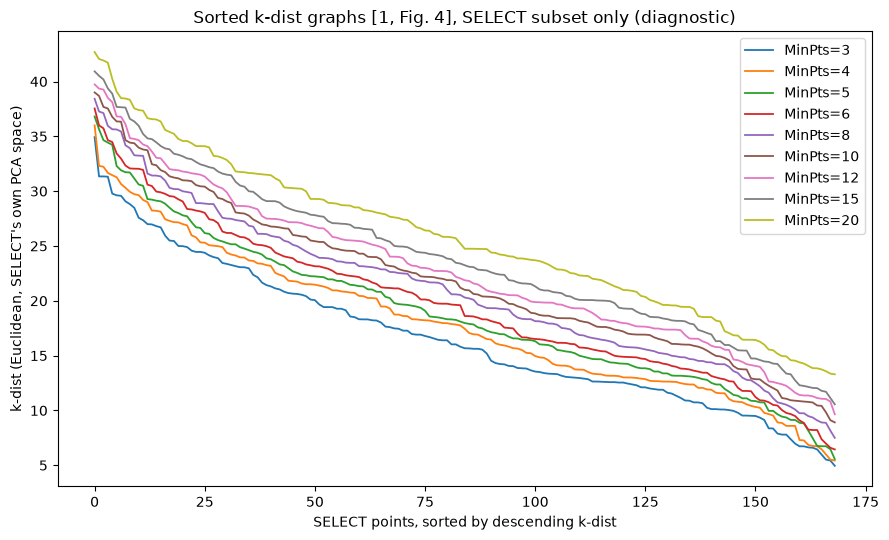

In [5]:
def sorted_kdist(X, k):
    '''Each point's distance to its k-th nearest neighbour [1, Sec 4.2], descending.'''
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(X)
    dist, _ = nn.kneighbors(X)
    return np.sort(dist[:, -1])[::-1]


def eps_from_noise_pct(kdist_desc, noise_pct):
    '''Ester et al.'s alternative, interactive rule [1, Sec 4.2]: eps is the k-dist
    value at the percentile of the sorted graph corresponding to an assumed noise
    percentage.'''
    idx = int(round(noise_pct / 100.0 * (len(kdist_desc) - 1)))
    return kdist_desc[idx]


MINPTS_CANDIDATES = [3, 4, 5, 6, 8, 10, 12, 15, 20]

kdist_curves_select = {k: sorted_kdist(X_pca_select, k) for k in MINPTS_CANDIDATES}

fig, ax = plt.subplots(figsize=(9, 5.5))
for k in MINPTS_CANDIDATES:
    ax.plot(np.arange(len(kdist_curves_select[k])), kdist_curves_select[k], lw=1.3, label=f"MinPts={k}")
ax.set_xlabel("SELECT points, sorted by descending k-dist")
ax.set_ylabel("k-dist (Euclidean, SELECT's own PCA space)")
ax.set_title("Sorted k-dist graphs [1, Fig. 4], SELECT subset only (diagnostic)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Selecting `(eps, MinPts)` by maximum average silhouette width [2], on `SELECT`

For every `(MinPts, noise%)` combination, `eps` is set to the `k-dist` value at that
noise percentile in **`SELECT`'s own PCA space**, DBSCAN [1] is fit **on `SELECT`
only**, and the resulting partition's **average silhouette width `S`** is computed
exactly as Rousseeuw [2] defines it:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}, \qquad S = \text{mean}_i\, s(i)$$

Rousseeuw [2] proposes choosing whichever candidate partition **maximises `S`** as
the most appropriate one. Because this maximisation only ever looks at `SELECT`, the
`HOLDOUT` entities play no part whatsoever in choosing `(eps, MinPts)` — which is
exactly what makes the Section 4.3 evaluation on `HOLDOUT` a fair, non-circular test,
per Stone (1974) [10]. Noise points are excluded from `S`, since they belong to no
cluster for `a(i)`/`b(i)` to be computed against (and `silhouette_score` requires at
least 2 labels present).

In [6]:
NOISE_PCT_CANDIDATES = [1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 50]
NOISE_CEILING = 0.90          # candidate rejected if >90% of SELECT ends up as noise
GIANT_CLUSTER_CEILING = 0.90  # or if one cluster holds >90% of SELECT's non-noise points
MIN_CLUSTERS = 2

rows = []
for k in MINPTS_CANDIDATES:
    kd = kdist_curves_select[k]
    for pct in NOISE_PCT_CANDIDATES:
        eps = eps_from_noise_pct(kd, pct)
        sel_labels = DBSCAN(eps=eps, min_samples=k, metric="euclidean").fit_predict(X_pca_select)

        non_noise = sel_labels != -1
        n_clusters = len(set(sel_labels[non_noise]))
        noise_frac = 1.0 - non_noise.mean()
        largest_frac = (pd.Series(sel_labels[non_noise]).value_counts(normalize=True).max()
                         if non_noise.any() else np.nan)

        sil = np.nan
        if n_clusters >= MIN_CLUSTERS and non_noise.sum() > n_clusters:
            sil = silhouette_score(X_pca_select[non_noise], sel_labels[non_noise], metric="euclidean")

        rows.append(dict(MinPts=k, noise_pct_rule=pct, eps=eps, n_clusters=n_clusters,
                          noise_frac=noise_frac, largest_frac=largest_frac, silhouette=sil))

grid = pd.DataFrame(rows)
print(f"Evaluated {len(grid)} (MinPts, eps) combinations on SELECT ({len(select_idx)} entities) only")
grid.sort_values("silhouette", ascending=False).head(10)

Evaluated 99 (MinPts, eps) combinations on SELECT (169 entities) only


,MinPts,noise_pct_rule,eps,n_clusters,noise_frac,largest_frac,silhouette
43,6,50,18.612336,2,0.366864,0.691589,0.522581
54,8,50,20.299322,2,0.337278,0.687500,0.516229
65,10,50,20.999070,2,0.313609,0.672414,0.509232
76,12,50,21.870594,2,0.284024,0.669421,0.492244
87,15,50,23.244122,2,0.254438,0.682540,0.474132
98,20,50,24.750219,2,0.218935,0.689394,0.453668
32,5,50,17.970252,3,0.396450,0.637255,0.371179
21,4,50,17.451848,3,0.414201,0.626263,0.370087
9,3,40,17.597947,5,0.325444,0.596491,0.288542
10,3,50,15.670603,5,0.467456,0.644444,0.237230


In [7]:
valid = grid[
    (grid["n_clusters"] >= MIN_CLUSTERS)
    & (grid["noise_frac"] <= NOISE_CEILING)
    & (grid["largest_frac"] <= GIANT_CLUSTER_CEILING)
    & grid["silhouette"].notna()
]
print(f"Non-degenerate combinations: {len(valid)} / {len(grid)}")

pool = valid if len(valid) else grid
if not len(valid):
    print("WARNING: every combination was degenerate by the ceilings above; "
          "picking the best of the full grid instead.")

best = pool.sort_values("silhouette", ascending=False).iloc[0]
MINPTS, BEST_NOISE_PCT = int(best["MinPts"]), int(best["noise_pct_rule"])
S_select = float(best["silhouette"])
print(f"\nSelected by maximum average silhouette width S [2], on SELECT only:")
print(f"  MinPts = {MINPTS}")
print(f"  noise-percentile rule = {BEST_NOISE_PCT}% [1, Sec 4.2]")
print(f"  (SELECT) clusters = {int(best['n_clusters'])}, noise = {best['noise_frac']:.1%}, "
      f"S_select = {S_select:.3f}")
print(f"\nNote: S_select is reported here for transparency about the selection process only.")
print(f"It is NOT the quality figure to trust -- it is measured on the same data used to")
print(f"choose these parameters, so it is optimistic by construction. See Section 4.3 for")
print(f"the honest, held-out estimate.")

Non-degenerate combinations: 10 / 99

Selected by maximum average silhouette width S [2], on SELECT only:
  MinPts = 6
  noise-percentile rule = 50% [1, Sec 4.2]
  (SELECT) clusters = 2, noise = 36.7%, S_select = 0.523

Note: S_select is reported here for transparency about the selection process only.
It is NOT the quality figure to trust -- it is measured on the same data used to
choose these parameters, so it is optimistic by construction. See Section 4.3 for
the honest, held-out estimate.


## 4.2 Two fits from here on: a held-out test, and the deployed clustering

The chosen `MinPts` and noise-percentile **rule** now feed two separate fits, kept
deliberately apart:

- **Held-out test fit (Section 4.3 below).** DBSCAN is fit on `SELECT` alone (`eps`
  re-derived on `SELECT`'s own k-dist graph at the chosen percentile), then
  `HOLDOUT` points — untouched by every step so far — are assigned to it using the
  paper's own density-reachability rule extended to new points (a point joins the
  cluster of its nearest *core* point if within `eps`, else it is noise; Definitions
  2-3 of [1]). Its silhouette is the honest quality estimate, since nothing about
  `HOLDOUT` fed into choosing `(eps, MinPts)`, the PCA basis, or the cluster
  structure itself.
- **Deployed fit (Section 6, Results).** A separate DBSCAN, fit on *all* entities
  (`StandardScaler`/PCA refit on the full data, `eps` re-derived the same way on the
  full data's own k-dist graph), is what actually clusters and reports on every
  company. It is the notebook's deliverable, but — precisely because the full data
  also helped choose `(eps, MinPts)` — its own silhouette score is descriptive only,
  never cited here as proof of quality.

In [8]:
eps_select_final = eps_from_noise_pct(kdist_curves_select[MINPTS], BEST_NOISE_PCT)
select_model = DBSCAN(eps=eps_select_final, min_samples=MINPTS, metric="euclidean")
select_labels = select_model.fit_predict(X_pca_select)

print(f"SELECT fit: eps={eps_select_final:.4f}, MinPts={MINPTS}")
print(f"  clusters: {len(set(select_labels[select_labels != -1]))}, "
      f"noise: {(select_labels == -1).mean():.1%} of {len(select_idx)} SELECT entities")

SELECT fit: eps=18.6123, MinPts=6
  clusters: 2, noise: 36.7% of 169 SELECT entities


## 4.3 Held-out evaluation — the non-circular quality estimate

`HOLDOUT` entities are assigned to the `SELECT`-fitted model by the density-
reachability rule above, never by refitting anything.

**Silhouette is computed twice, deliberately in this order:**

1. **Before removing DBSCAN's noise** — over *all* of `HOLDOUT`, treating noise
   (`label == -1`) as its own group. `silhouette_score` [2, 4] does not know or care
   that `-1` means "noise"; it is just another label, so this is a direct, unmodified
   application of the same cited formula, over 100% of `HOLDOUT`, that a(i)/b(i) [2]
   are well-defined for. This is the whole-sample figure.
2. **After removing noise** — restricted to the entities DBSCAN actually placed in a
   cluster. This is narrower by construction (Rousseeuw's [2] original `a(i)`/`b(i)`
   assume cluster membership, so a noise point has no natural `a(i)` under that
   original definition), and is reported with its coverage so it is never mistaken
   for a whole-sample number.

In [9]:
core_coords = X_pca_select[select_model.core_sample_indices_]
core_labels = select_labels[select_model.core_sample_indices_]

nn_core = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(core_coords)
dist_to_core, idx_to_core = nn_core.kneighbors(X_pca_holdout)
holdout_labels = np.where(dist_to_core[:, 0] <= eps_select_final,
                           core_labels[idx_to_core[:, 0]], -1)

holdout_non_noise = holdout_labels != -1
holdout_coverage = holdout_non_noise.mean()
n_holdout_clusters = len(set(holdout_labels[holdout_non_noise]))
n_unique_holdout = len(set(holdout_labels))

print(f"HOLDOUT: {len(holdout_idx)} entities, of which {holdout_non_noise.sum()} "
      f"({holdout_coverage:.1%}) were assigned to one of {n_holdout_clusters} clusters; "
      f"{(~holdout_non_noise).sum()} ({1 - holdout_coverage:.1%}) are noise.\n")

# 1. Silhouette BEFORE removing noise -- all of HOLDOUT, noise as its own group.
if 1 < n_unique_holdout < len(holdout_labels):
    S_holdout_all = silhouette_score(X_pca_holdout, holdout_labels, metric="euclidean")
    print(f"Held-out silhouette, noise included as its own group [2, 4] = {S_holdout_all:.3f}  "
          f"(coverage: 100% of HOLDOUT, {len(holdout_idx)}/{len(holdout_idx)} entities)")
else:
    S_holdout_all = np.nan
    print("Held-out silhouette including noise: undefined (fewer than 2 distinct groups in HOLDOUT).")

# 2. Silhouette AFTER removing noise -- restricted to non-noise HOLDOUT entities.
if n_holdout_clusters >= MIN_CLUSTERS and holdout_non_noise.sum() > n_holdout_clusters:
    S_holdout = silhouette_score(X_pca_holdout[holdout_non_noise], holdout_labels[holdout_non_noise],
                                  metric="euclidean")
    ch_holdout = calinski_harabasz_score(X_pca_holdout[holdout_non_noise], holdout_labels[holdout_non_noise])
    db_holdout = davies_bouldin_score(X_pca_holdout[holdout_non_noise], holdout_labels[holdout_non_noise])
    print(f"Held-out silhouette, noise removed [2, 4]                    = {S_holdout:.3f}  "
          f"(coverage: {holdout_non_noise.sum()}/{len(holdout_idx)} = {holdout_coverage:.1%} of HOLDOUT)")
    print(f"Held-out Calinski-Harabasz index [6, 4] (noise removed)      = {ch_holdout:.1f}  (same coverage)")
    print(f"Held-out Davies-Bouldin index [7, 4] (noise removed)         = {db_holdout:.3f}  (same coverage)")
    print(f"\nThese, not S_select above, are this notebook's evidence of clustering quality: "
          f"none of the {len(holdout_idx)} HOLDOUT entities took part in choosing (eps, MinPts), "
          f"fitting PCA, or fitting the SELECT model.")
else:
    S_holdout = np.nan
    print("\nHOLDOUT produced fewer than 2 clusters after removing noise -- that narrower silhouette "
          "is undefined for this upload. The whole-sample figure above (noise included) and the "
          "coverage figures are still the honest, non-circular quality signal.")

HOLDOUT: 72 entities, of which 52 (72.2%) were assigned to one of 2 clusters; 20 (27.8%) are noise.

Held-out silhouette, noise included as its own group [2, 4] = 0.273  (coverage: 100% of HOLDOUT, 72/72 entities)
Held-out silhouette, noise removed [2, 4]                    = 0.505  (coverage: 52/72 = 72.2% of HOLDOUT)
Held-out Calinski-Harabasz index [6, 4] (noise removed)      = 69.1  (same coverage)
Held-out Davies-Bouldin index [7, 4] (noise removed)         = 0.743  (same coverage)

These, not S_select above, are this notebook's evidence of clustering quality: none of the 72 HOLDOUT entities took part in choosing (eps, MinPts), fitting PCA, or fitting the SELECT model.


## 5. Cluster-stability analysis

Neither [1] nor [2] addresses stability, so this section is built entirely from two
standard, separately-cited techniques:

- **Sub-sampling** is the practical, no-duplicates variant of **Efron's (1979)
  bootstrap** [9]: draw a random `frac` of the entities *without* replacement (a
  literal bootstrap, sampling *with* replacement, would create duplicate points,
  artificially inflating the neighbour counts a density-based method like DBSCAN
  relies on).
- Agreement between the resulting partition and the original one, on the entities
  they share, is measured with the **Adjusted Rand Index (ARI)** [8], exactly as
  implemented by `sklearn.metrics.adjusted_rand_score` [4].

On each of `B` replicates, the **entire** pipeline — `StandardScaler` -> PCA [5] ->
DBSCAN [1] — is refit from scratch on the subsample (of *all* entities; this section
tests robustness to which companies are included, a different question from Section
4.3's out-of-sample generalisation test), so what is being tested is the stability of
the whole procedure, not just of DBSCAN in isolation.

**`eps` cannot simply be reused across replicates**, for the same reason `eps` is
re-derived for `SELECT` and for the full data separately above: PCA is refit from
scratch on each subsample, so its components — and the distance scale they induce —
are not the same PCA space any previously-computed `eps` was calibrated to. What is
held fixed instead is the **selection rule**: the same `MinPts` and the same
noise-percentile [1, Sec 4.2] chosen in Section 4.1 (`BEST_NOISE_PCT`) are re-applied
to each subsample's own sorted k-dist graph, so `eps` is re-derived freshly, on its
own PCA space, every time.

The subsample's labels are then compared via ARI [8] to the full-data deployed
model's labels (Section 6), restricted to that same subsample of entities. `ARI = 1`
means perfect agreement (up to relabelling), `ARI ~ 0` matches what two independent
random partitions would give, and it can dip slightly negative.

In [10]:
def stability_analysis(X_features, minpts, noise_pct, labels_full, B=30, frac=0.8, seed=RANDOM_STATE):
    rng_local = np.random.default_rng(seed)
    n_local = X_features.shape[0]
    m = int(round(frac * n_local))
    scores = []
    for _ in range(B):
        idx = rng_local.choice(n_local, size=m, replace=False)
        _, _, sub_pca = fit_scaler_pca(X_features[idx], seed=seed)

        # Re-derive eps on THIS subsample's own PCA space, using the same
        # (MinPts, noise-percentile) rule [1, Sec 4.2] selected in Section 4.1 --
        # reusing a previously-computed eps number here would be invalid, since
        # PCA was just refit and its distance scale is not guaranteed to match.
        kd_sub = sorted_kdist(sub_pca, minpts)
        eps_sub = eps_from_noise_pct(kd_sub, noise_pct)

        sub_labels = DBSCAN(eps=eps_sub, min_samples=minpts, metric="euclidean").fit_predict(sub_pca)
        scores.append(adjusted_rand_score(labels_full[idx], sub_labels))
    return np.array(scores)

## 6. The deployed clustering (all entities)

A separate DBSCAN fit, this time on *every* uploaded entity: `StandardScaler`/PCA [5]
refit on the full data, `eps` re-derived (same rule, same helper functions as
throughout) on the full data's own k-dist graph at the `BEST_NOISE_PCT` chosen in
Section 4.1. This is the clustering the rest of this notebook reports and visualises.
Its own internal silhouette score is shown later purely as a description of the
output, not as evidence of quality — that evidence is Section 4.3's held-out result,
since this fit reuses the same full data that helped choose `(eps, MinPts)`.

As in Section 4, fitting DBSCAN assigns every entity exactly one of the three roles
defined in the paper (Section 3 of [1]): a **core point** if its neighbourhood held
at least `MinPts` points (`core_sample_indices_` in scikit-learn [3]); a **border
point** if it is density-reachable from a core point but is not one itself; or
**noise** (`label == -1`) if it is reachable from no core point at all.

Deployed fit (all 241 entities): eps=17.7285, MinPts=6
1 clusters found
  core points:    120 (49.8%)
  border points:   35 (14.5%)
  noise points:    86 (35.7%)

Cluster sizes:
0    155
Name: n_entities, dtype: int64



Cluster-stability analysis (B=30 sub-samples [9] of 80% of entities, eps re-derived per subsample via the same MinPts=6 / 50% noise rule [1], agreement via ARI [8]):
  mean ARI = 0.624
  std  ARI = 0.165
  min / max ARI = 0.422 / 0.938


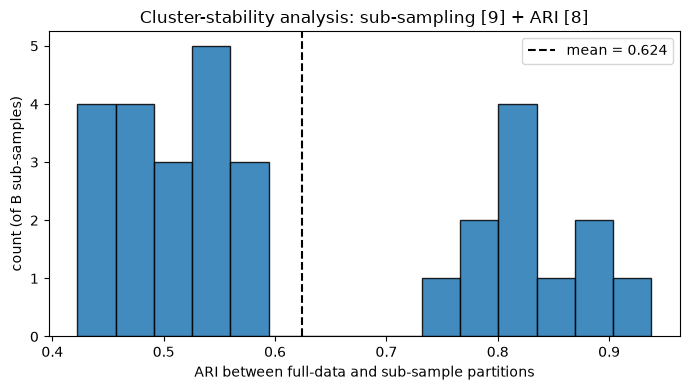

=> The clustering shows moderate stability; some cluster structure is sample-dependent.


In [11]:
scaler_full, pca_full, X_pca = fit_scaler_pca(X_raw)
eps_full = eps_from_noise_pct(sorted_kdist(X_pca, MINPTS), BEST_NOISE_PCT)

final = DBSCAN(eps=eps_full, min_samples=MINPTS, metric="euclidean")
labels = final.fit_predict(X_pca)
n = len(labels)

is_core = np.zeros(n, dtype=bool)
is_core[final.core_sample_indices_] = True
is_border = (~is_core) & (labels != -1)
is_noise = labels == -1

cluster_ids = sorted(set(labels[labels != -1]))
n_clusters = len(cluster_ids)
sizes = pd.Series(labels[labels != -1]).value_counts().sort_index()

print(f"Deployed fit (all {n} entities): eps={eps_full:.4f}, MinPts={MINPTS}")
print(f"{n_clusters} clusters found")
print(f"  core points:   {is_core.sum():>4d} ({is_core.mean():.1%})")
print(f"  border points: {is_border.sum():>4d} ({is_border.mean():.1%})")
print(f"  noise points:  {is_noise.sum():>4d} ({is_noise.mean():.1%})")
print("\nCluster sizes:")
print(sizes.rename("n_entities"))

stability_scores = stability_analysis(X_raw, MINPTS, BEST_NOISE_PCT, labels, B=30, frac=0.8)
print(f"\nCluster-stability analysis (B=30 sub-samples [9] of 80% of entities, "
      f"eps re-derived per subsample via the same MinPts={MINPTS} / "
      f"{BEST_NOISE_PCT}% noise rule [1], agreement via ARI [8]):")
print(f"  mean ARI = {stability_scores.mean():.3f}")
print(f"  std  ARI = {stability_scores.std():.3f}")
print(f"  min / max ARI = {stability_scores.min():.3f} / {stability_scores.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(stability_scores, bins=15, color="C0", edgecolor="k", alpha=0.85)
ax.axvline(stability_scores.mean(), color="k", ls="--", lw=1.5,
           label=f"mean = {stability_scores.mean():.3f}")
ax.set_xlabel("ARI between full-data and sub-sample partitions")
ax.set_ylabel("count (of B sub-samples)")
ax.set_title("Cluster-stability analysis: sub-sampling [9] + ARI [8]")
ax.legend()
plt.tight_layout()
plt.show()

if stability_scores.mean() > 0.7:
    print("=> The clustering is highly stable under 20% data removal and a full pipeline refit.")
elif stability_scores.mean() > 0.4:
    print("=> The clustering shows moderate stability; some cluster structure is sample-dependent.")
else:
    print("=> The clustering is not very stable; treat the specific clusters found with caution.")

## 7. Results

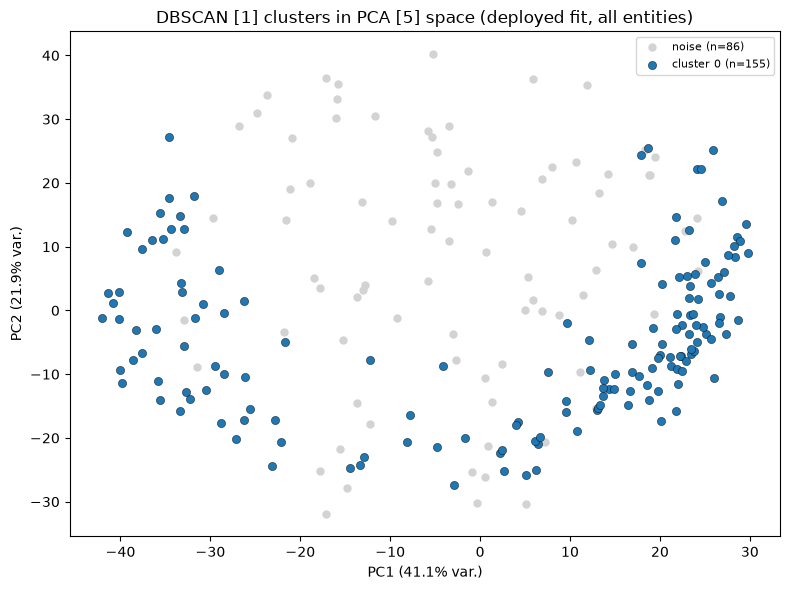

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[is_noise, 0], X_pca[is_noise, 1], c="lightgray", s=25,
           label=f"noise (n={is_noise.sum()})", zorder=1)
for c in cluster_ids:
    m = labels == c
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=f"C{c % 10}", s=35,
               label=f"cluster {c} (n={m.sum()})", zorder=2, edgecolor="k", linewidth=0.3)
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("DBSCAN [1] clusters in PCA [5] space (deployed fit, all entities)")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

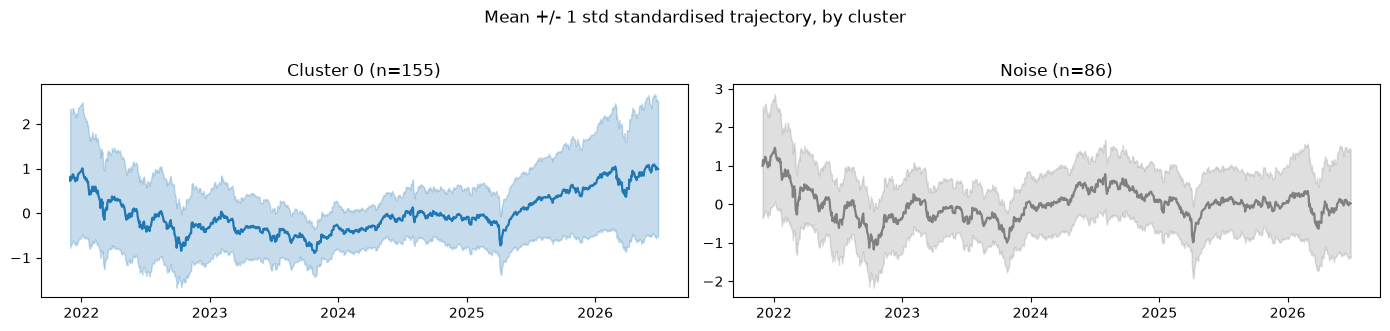

In [13]:
try:
    t_axis = pd.to_datetime(feature_cols)
except (ValueError, TypeError):
    t_axis = np.arange(X_raw.shape[1])

n_panels = n_clusters + 1
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows), squeeze=False)

panel = 0
for c in cluster_ids:
    ax = axes[panel // n_cols][panel % n_cols]
    mem = X_raw[labels == c]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(t_axis, mu, color=f"C{c % 10}", lw=1.6)
    ax.fill_between(t_axis, mu - sd, mu + sd, color=f"C{c % 10}", alpha=0.25)
    ax.set_title(f"Cluster {c} (n={mem.shape[0]})")
    panel += 1

ax = axes[panel // n_cols][panel % n_cols]
mem = X_raw[is_noise]
mu, sd = mem.mean(axis=0), mem.std(axis=0)
ax.plot(t_axis, mu, color="gray", lw=1.6)
ax.fill_between(t_axis, mu - sd, mu + sd, color="gray", alpha=0.25)
ax.set_title(f"Noise (n={mem.shape[0]})")
panel += 1

for p in range(panel, n_rows * n_cols):
    axes[p // n_cols][p % n_cols].axis("off")

fig.suptitle("Mean +/- 1 std standardised trajectory, by cluster", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
for c in cluster_ids:
    mem = sorted(str(x) for x in entity_ids[labels == c])
    print(f"Cluster {c} (n={len(mem)}):")
    print(textwrap.fill(", ".join(mem), width=95))
    print()

noise_members = sorted(str(x) for x in entity_ids[is_noise])
print(f"Noise (n={len(noise_members)}):")
print(textwrap.fill(", ".join(noise_members), width=95))

Cluster 0 (n=155):
3IN.L, AAS.L, AEP.L, AGT.L, AIE.L, AJB.L, AO.L, ASL.L, ATR.L, ATT.L, ATYM.L, AVON.L, BAG.L,
BBY.L, BCG.L, BGFD.L, BME.L, BNKR.L, BPCR.L, BRWM.L, BSIF.L, BUT.L, BYG.L, CBG.L, CGT.L, CHG.L,
CKN.L, CLDN.L, COST.L, CSN.L, CTY.L, CURY.L, CVSG.L, CWK.L, CWR.L, DLN.L, DOCS.L, DRX.L,
DSCV.L, EDIN.L, ELM.L, ESCT.L, EWI.L, FAN.L, FCH.L, FCSS.L, FEML.L, FEV.L, FGEN.L, FSV.L,
GBG.L, GCP.L, GDWN.L, GFRD.L, GNC.L, GNS.L, GPE.L, GRI.L, GROW.L, GSCT.L, HANA.L, HAS.L,
HFEL.L, HGT.L, HICL.L, HILS.L, HOC.L, HRI.L, HSL.L, HTWS.L, HVPE.L, IAD.L, ICGT.L, INPP.L,
IPF.L, IPO.L, JAM.L, JCH.L, JEDT.L, JEGI.L, JEMI.L, JFJ.L, JGGI.L, JMGI.L, JSG.L, JTC.L, JUP.L,
KIE.L, KLR.L, KNOS.L, LWDB.L, MGNS.L, MNDI.L, MNKS.L, MNTN.L, MRC.L, MTO.L, MUT.L, MYI.L,
N91.L, OCDO.L, OCI.L, ONT.L, OXB.L, PAF.L, PAG.L, PAGE.L, PETS.L, PFD.L, PHI.L, PHP.L, PIN.L,
PLUS.L, PNL.L, PNN.L, PPET.L, QLT.L, QQ.L, RCP.L, RS1.L, RTW.L, SAFE.L, SAGA.L, SDP.L, SEIT.L,
SEQI.L, SMWH.L, SNR.L, SOI.L, SRP.L, SSPG.L, SUPR.L, SYNC.L

## 8. Evaluation metrics

**The held-out figures in Section 4.3 are this notebook's quality evidence.** What
follows is the same family of metrics computed on the deployed, full-data fit from
Section 6 — useful for *describing* the delivered clustering and for the Rousseeuw
[2] silhouette plot, but **not** independent evidence of quality, since the full data
shown here also helped choose `(eps, MinPts)` in Section 4.1. Every number below is
reported with its coverage for the same reason given in Section 4.3: the silhouette
coefficient is undefined for noise points by Rousseeuw's own definition [2], so a
score computed only on the non-noise share of the data is never presented as if it
covered everyone.

### 8.1 Silhouette [2] (descriptive, deployed fit) — before, then after, removing noise

As in Section 4.3, silhouette is computed twice: first over **all** entities, with
noise treated as its own group (a direct, unmodified use of `silhouette_score` [2, 4]
— it needs only >= 2 distinct labels, and does not know `-1` is meant as "noise"),
and only afterwards restricted to the non-noise entities for the Rousseeuw-style
plot, since the plot's per-cluster bars (Figs. 2-5, 7 of [2]) are only meaningful for
DBSCAN's actual clusters.

In [15]:
non_noise = labels != -1
coverage = non_noise.mean()

# 1. Silhouette BEFORE removing noise -- all entities, noise as its own group.
n_unique_all = len(set(labels))
if 1 < n_unique_all < n:
    S_all_incl_noise = silhouette_score(X_pca, labels, metric="euclidean")
    print(f"Deployed-fit silhouette, noise included as its own group [2, 4] = {S_all_incl_noise:.3f}  "
          f"(coverage: 100% of entities, {n}/{n})")
else:
    S_all_incl_noise = np.nan
    print("Deployed-fit silhouette including noise: undefined (fewer than 2 distinct groups).")

# 2. Silhouette AFTER removing noise -- restricted to non-noise entities.
if n_clusters >= MIN_CLUSTERS and non_noise.sum() > n_clusters:
    sv = silhouette_samples(X_pca[non_noise], labels[non_noise], metric="euclidean")
    S_overall = sv.mean()
    print(f"Deployed-fit silhouette, noise removed [2, 4]                   = {S_overall:.3f}  "
          f"(coverage: {non_noise.sum()}/{n} = {coverage:.1%} of all entities -- "
          f"the remaining {n - non_noise.sum()} ({1 - coverage:.1%}) are noise and are excluded here, "
          f"since s(i) is undefined for a point that belongs to no cluster under Rousseeuw's [2] "
          f"original definition.)")
    print("\nBoth numbers above are descriptive only -- see Section 4.3 for the non-circular, "
          "held-out quality estimate.")

    fig, ax = plt.subplots(figsize=(9, 0.35 * non_noise.sum() + 2))
    y0 = 0
    for c in cluster_ids:
        v = np.sort(sv[labels[non_noise] == c])[::-1]     # decreasing s(i), as in [2]
        y = np.arange(y0, y0 + len(v))
        ax.fill_betweenx(y, 0, v, color=f"C{c % 10}", alpha=0.85)
        ax.text(-0.05, y0 + len(v) / 2, f"cluster {c}\n(n={len(v)}, avg s={v.mean():.2f})",
                ha="right", va="center", fontsize=8)
        y0 += len(v) + 3

    ax.axvline(S_overall, color="k", ls="--", lw=1,
               label=f"overall average silhouette width S (noise removed) = {S_overall:.3f}")
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlim(-1, 1)
    ax.set_yticks([])
    ax.set_xlabel("s(i)")
    ax.set_title("Silhouette plot [2] of the deployed DBSCAN [1] clustering (descriptive, noise removed)")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    S_overall = np.nan
    print(f"Deployed-fit silhouette, noise removed: undefined (only {n_clusters} cluster(s) found "
          f"among the non-noise entities). The whole-sample figure above (noise included) is still "
          f"well-defined and is shown instead of a per-cluster plot.")

Deployed-fit silhouette, noise included as its own group [2, 4] = 0.093  (coverage: 100% of entities, 241/241)
Deployed-fit silhouette, noise removed: undefined (only 1 cluster(s) found among the non-noise entities). The whole-sample figure above (noise included) is still well-defined and is shown instead of a per-cluster plot.


### 8.2 Calinski-Harabasz [6] and Davies-Bouldin [7] indices (descriptive, deployed fit)

Both are implemented by scikit-learn [4] alongside the silhouette score, and both
need feature vectors in Euclidean space rather than a precomputed distance matrix —
satisfied here directly, since clustering itself was already done on the Euclidean
PCA [5] coordinates `X_pca`. One documented caveat from scikit-learn's guide [4]
applies directly to this notebook: all of these indices are *"generally higher for
convex clusters than other concepts of clusters, such as density-based clusters like
those obtained through DBSCAN"* — so read the numbers below as descriptive, and
alongside Section 4.3's held-out figures, not as an absolute mark of quality.

In [16]:
if n_clusters >= MIN_CLUSTERS and non_noise.sum() > n_clusters:
    ch = calinski_harabasz_score(X_pca[non_noise], labels[non_noise])
    db = davies_bouldin_score(X_pca[non_noise], labels[non_noise])

    print(f"Deployed-fit silhouette, noise included [2, 4] (higher is better, in [-1, 1]): "
          f"{S_all_incl_noise:.3f}  (coverage 100%)")
    print(f"Deployed-fit silhouette, noise removed [2, 4]:                                "
          f"{S_overall:.3f}  (coverage {coverage:.1%})")
    print(f"Deployed-fit Calinski-Harabasz [6, 4] (higher is better):                     "
          f"{ch:.1f}   (coverage {coverage:.1%})")
    print(f"Deployed-fit Davies-Bouldin [7, 4] (lower is better, >= 0):                    "
          f"{db:.3f}  (coverage {coverage:.1%})")
else:
    print(f"Deployed-fit silhouette, noise included [2, 4] (higher is better, in [-1, 1]): "
          f"{S_all_incl_noise:.3f}  (coverage 100%)")
    print("Calinski-Harabasz and Davies-Bouldin need >= 2 non-noise clusters; only "
          f"{n_clusters} found among the non-noise entities for this upload, so they are undefined here.")
print(f"\nFor the honest, non-circular quality estimate, see Section 4.3's held-out figures.")

Deployed-fit silhouette, noise included [2, 4] (higher is better, in [-1, 1]): 0.093  (coverage 100%)
Calinski-Harabasz and Davies-Bouldin need >= 2 non-noise clusters; only 1 found among the non-noise entities for this upload, so they are undefined here.

For the honest, non-circular quality estimate, see Section 4.3's held-out figures.


### 8.3 Adjusted Rand Index [8] against a naive trend baseline

A final external sanity check, in the spirit of `adjusted_rand_score`'s [4] intended
use of comparing two independent partitions of the same objects: does DBSCAN [1] just
rediscover the sign of each entity's overall trend, or capture something a trivial
rule would miss?

In [17]:
t_full = np.arange(X_raw.shape[1])
trend = np.array([np.polyfit(t_full, row, 1)[0] for row in X_raw])
trend_sign = (trend > 0).astype(int)

ari_trend = adjusted_rand_score(labels, trend_sign)   # noise (-1) counted as its own group
print(f"ARI(DBSCAN clusters incl. noise, sign-of-trend) [8] = {ari_trend:.3f}")
if ari_trend > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari_trend > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing movement structure beyond simple trend direction.")

ARI(DBSCAN clusters incl. noise, sign-of-trend) [8] = 0.036
=> The clustering is capturing movement structure beyond simple trend direction.


## References

**Supplied for this task:**

1. M. Ester, H.-P. Kriegel, J. Sander, X. Xu (1996). *A Density-Based Algorithm for
   Discovering Clusters in Large Spatial Databases with Noise.* KDD-96.
2. P. J. Rousseeuw (1987). *Silhouettes: A Graphical Aid to the Interpretation and
   Validation of Cluster Analysis.* Journal of Computational and Applied Mathematics,
   20, 53-65.
3. scikit-learn developers. *Clustering* (`sklearn.cluster.DBSCAN`), scikit-learn
   User Guide. https://scikit-learn.org/stable/modules/clustering.html#dbscan
4. scikit-learn developers. *Clustering performance evaluation*, scikit-learn User
   Guide. https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation

**Standard supporting references** (for methods requested that [1]-[4] do not cover;
not among the materials supplied):

5. K. Pearson (1901). *On lines and planes of closest fit to systems of points in
   space.* Philosophical Magazine, 2(11), 559-572. — origin of PCA.
6. T. Calinski & J. Harabasz (1974). *A dendrite method for cluster analysis.*
   Communications in Statistics, 3(1), 1-27. — origin of the Calinski-Harabasz index,
   as implemented and cited by [4].
7. D. L. Davies & D. W. Bouldin (1979). *A Cluster Separation Measure.* IEEE
   Transactions on Pattern Analysis and Machine Intelligence, PAMI-1(2), 224-227. —
   origin of the Davies-Bouldin index, as implemented and cited by [4].
8. L. Hubert & P. Arabie (1985). *Comparing partitions.* Journal of Classification,
   2(1), 193-218. — origin of the (Adjusted) Rand Index, as implemented and cited by
   [4].
9. B. Efron (1979). *Bootstrap methods: another look at the jackknife.* The Annals of
   Statistics, 7(1), 1-26. — origin of resampling-based stability assessment,
   adapted here to sub-sampling without replacement for the reason given in Section 5.
10. M. Stone (1974). *Cross-Validatory Choice and Assessment of Statistical
    Predictions.* Journal of the Royal Statistical Society, Series B, 36(2), 111-147.
    — origin of the hold-out/cross-validation principle that model selection and
    performance evaluation must use disjoint data, applied in Sections 3-4.3 to keep
    the eps/MinPts selection and the quality evaluation from touching the same
    entities.
